In [4]:
#Data loading and initial inspection

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the dataset
df = pd.read_csv("data/raw/us_pollution.csv")

In [7]:
# Filter to only keep data from 2022 onwards to meet row limit
df = df[df["Date"] >= "2022-01-01"]
df = df.reset_index(drop=True)

print("New shape:", df.shape)

New shape: (44726, 22)


In [8]:
# Basic inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names and data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

Shape: (44726, 22)

First 5 rows:
   Unnamed: 0        Date                                Address    State  \
0      620688  2022-01-01  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
1      620689  2022-01-02  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
2      620690  2022-01-04  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
3      620691  2022-01-05  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
4      620692  2022-01-06  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   

      County        City   O3 Mean  O3 1st Max Value  O3 1st Max Hour  O3 AQI  \
0  Jefferson  Birmingham  0.024765             0.026               21      24   
1  Jefferson  Birmingham  0.017824             0.025               23      23   
2  Jefferson  Birmingham  0.025353             0.030               10      28   
3  Jefferson  Birmingham  0.012563             0.034                8      31   
4  Jefferson  Birmingham  0.023941             0.028               18      26   

   ...  CO 1st M

In [9]:
# pd.Series and pd.DataFrame 
pollutants = pd.Series(["NO2", "O3", "SO2", "CO"], name="Tracked Pollutants")
print("\nPollutants tracked in this dataset:")
print(pollutants)

health_info = pd.DataFrame({
    "Pollutant": ["NO2", "O3", "SO2", "CO"],
    "Health Effect": [
        "Respiratory inflammation",
        "Lung tissue damage",
        "Throat and eye irritation",
        "Reduces oxygen in bloodstream"
    ],
    "EPA Limit (AQI)": [100, 100, 100, 100]
})
print("\nPollutant health reference table:")
print(health_info)


Pollutants tracked in this dataset:
0    NO2
1     O3
2    SO2
3     CO
Name: Tracked Pollutants, dtype: str

Pollutant health reference table:
  Pollutant                  Health Effect  EPA Limit (AQI)
0       NO2       Respiratory inflammation              100
1        O3             Lung tissue damage              100
2       SO2      Throat and eye irritation              100
3        CO  Reduces oxygen in bloodstream              100


In [10]:
# Type conversions
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Extract month and year columns for later grouping
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Convert AQI columns to numeric
aqi_cols = ["O3 AQI", "CO AQI", "SO2 AQI", "NO2 AQI"]
for col in aqi_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["State"] = df["State"].astype("category")

print("Date range:", df["Date"].min(), "→", df["Date"].max())
print("dtypes after conversion:\n", df[["Date","Year","Month"] + aqi_cols].dtypes)
print("\nState dtype:", df["State"].dtype)

Date range: 2022-01-01 00:00:00 → 2023-09-30 00:00:00
dtypes after conversion:
 Date       datetime64[us]
Year                int32
Month               int32
O3 AQI              int64
CO AQI            float64
SO2 AQI           float64
NO2 AQI             int64
dtype: object

State dtype: category


In [11]:
# Missing value handling 
print("Missing values BEFORE:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Strategy 1: Drop rows where ALL AQI columns are null (unusable rows)
df.dropna(subset=aqi_cols, how="all", inplace=True)

# Strategy 2: Fill remaining AQI nulls with column median
for col in aqi_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values AFTER:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Shape after cleaning:", df.shape)

Missing values BEFORE:
 Series([], dtype: int64)

Missing values AFTER:
 Series([], dtype: int64)
Shape after cleaning: (44726, 24)


In [12]:
# Derive new columns

# np.where: classify O3 AQI as Good / Moderate / Unhealthy
df["O3_Category"] = np.where(df["O3 AQI"] <= 50, "Good",
                    np.where(df["O3 AQI"] <= 100, "Moderate", "Unhealthy"))

# .apply: compute an average AQI score across all 4 pollutants
df["Avg_AQI"] = df[aqi_cols].apply(lambda row: row.mean(), axis=1)

print(df[["Date", "State", "O3 AQI", "O3_Category", "Avg_AQI"]].head(10))
print("\nO3 Category distribution:\n", df["O3_Category"].value_counts())

        Date    State  O3 AQI O3_Category  Avg_AQI
0 2022-01-01  Alabama      24        Good     6.50
1 2022-01-02  Alabama      23        Good     7.25
2 2022-01-04  Alabama      28        Good     9.75
3 2022-01-05  Alabama      31        Good    16.25
4 2022-01-06  Alabama      26        Good    13.50
5 2022-01-07  Alabama      23        Good    11.75
6 2022-01-08  Alabama      31        Good    15.00
7 2022-01-09  Alabama      24        Good     9.75
8 2022-01-11  Alabama      29        Good    13.75
9 2022-01-12  Alabama      30        Good    18.25

O3 Category distribution:
 O3_Category
Good         38377
Moderate      5528
Unhealthy      821
Name: count, dtype: int64


In [13]:
# Indexing examples

# .loc — label-based: filter to Florida rows
florida = df.loc[df["State"] == "Florida"]
print("Florida rows:", florida.shape)
print(florida[["Date","City","O3 AQI","NO2 AQI"]].head())

# .iloc — position-based: first 5 rows, first 6 columns
print("\nFirst 5 rows, first 6 cols (iloc):")
print(df.iloc[:5, :6])

Florida rows: (373, 26)
            Date   City  O3 AQI  NO2 AQI
10974 2022-06-01  Davie      36        8
10975 2022-06-02  Davie      35       16
10976 2022-06-03  Davie      18        8
10977 2022-06-04  Davie      21        3
10978 2022-06-05  Davie      31        6

First 5 rows, first 6 cols (iloc):
   Unnamed: 0       Date                                Address    State  \
0      620688 2022-01-01  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
1      620689 2022-01-02  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
2      620690 2022-01-04  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
3      620691 2022-01-05  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   
4      620692 2022-01-06  NO. B'HAM,SOU R.R., 3009 28TH ST. NO.  Alabama   

      County        City  
0  Jefferson  Birmingham  
1  Jefferson  Birmingham  
2  Jefferson  Birmingham  
3  Jefferson  Birmingham  
4  Jefferson  Birmingham  


In [14]:
# Multi-column aggregation - mean and count of Avg_AQI by State + Year
state_year = (df.groupby(["State", "Year"])["Avg_AQI"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "Mean_AQI", "count": "Days"})
                .reset_index())

print(state_year.head(10))

         State  Year   Mean_AQI  Days
0      Alabama  2022  15.484058   345
1      Alabama  2023  17.001404   178
2      Arizona  2022  19.267348  1052
3      Arizona  2023  20.788628   576
4     Arkansas  2022  14.018169   344
5   California  2022  16.620967  7190
6   California  2023  14.521133  3336
7     Colorado  2022  19.674250   967
8     Colorado  2023  20.531631   656
9  Connecticut  2022  15.852227   247


In [15]:
# Pivot - Mean AQI by State x Year
pivot = state_year.pivot_table(
    index="State",
    columns="Year",
    values="Mean_AQI"
)
print("Mean AQI by State x Year:")
print(pivot.round(1).head(10))

Mean AQI by State x Year:
Year                  2022  2023
State                           
Alabama               15.5  17.0
Arizona               19.3  20.8
Arkansas              14.0   NaN
California            16.6  14.5
Colorado              19.7  20.5
Connecticut           15.9  15.5
Delaware              15.2   NaN
District Of Columbia  15.4  17.2
Florida               11.0  14.8
Georgia               15.0  16.7


In [16]:
import os
# Save cleaned dataset
os.makedirs("data/processed", exist_ok=True) # Ensure directory exists
df.to_csv("data/processed/us_pollution_cleaned.csv", index=False)
print("Saved to data/processed/us_pollution_cleaned.csv")

Saved to data/processed/us_pollution_cleaned.csv


In [17]:
# Section 3: Descriptive Statistics & Simple EDA

In [18]:
# Numeric columns to analyze
numeric_cols = ["O3 AQI", "CO AQI", "SO2 AQI", "NO2 AQI", "Avg_AQI"]

print("Overall .describe():")
print(df[numeric_cols].describe().round(2))
 
print("\nExplicit stats per column:") # Providing mean, median, std, min, max for each numeric column
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  mean   = {df[col].mean():.2f}")
    print(f"  median = {df[col].median():.2f}")
    print(f"  std    = {df[col].std():.2f}")
    print(f"  min    = {df[col].min():.2f}")
    print(f"  max    = {df[col].max():.2f}")

Overall .describe():
         O3 AQI    CO AQI   SO2 AQI   NO2 AQI   Avg_AQI
count  44726.00  44726.00  44726.00  44726.00  44726.00
mean      40.26      3.69      0.69     17.71     15.59
std       18.87      2.79      1.82     11.89      5.97
min        0.00      0.00      0.00      0.00      2.25
25%       30.00      2.00      0.00      8.00     11.50
50%       37.00      3.00      0.00     15.00     14.75
75%       45.00      5.00      1.00     25.00     18.25
max      217.00     41.00    118.00    153.00     63.50

Explicit stats per column:

O3 AQI:
  mean   = 40.26
  median = 37.00
  std    = 18.87
  min    = 0.00
  max    = 217.00

CO AQI:
  mean   = 3.69
  median = 3.00
  std    = 2.79
  min    = 0.00
  max    = 41.00

SO2 AQI:
  mean   = 0.69
  median = 0.00
  std    = 1.82
  min    = 0.00
  max    = 118.00

NO2 AQI:
  mean   = 17.71
  median = 15.00
  std    = 11.89
  min    = 0.00
  max    = 153.00

Avg_AQI:
  mean   = 15.59
  median = 14.75
  std    = 5.97
  min    = 2.25


In [19]:
print("Mean AQI stats grouped by O3 Category:")
# Group by O3_Category and calculate mean and median for numeric columns
group_stats = (df.groupby("O3_Category")[numeric_cols]
                 .agg(["mean", "median"])
                 .round(2))
print(group_stats)

# Group by State and calculate mean, median, std, count for Avg_AQI
print("\nMean Avg_AQI by State (top 10):")
state_stats = (df.groupby("State")["Avg_AQI"]
                 .agg(["mean", "median", "std", "count"])
                 .round(2)
                 .sort_values("mean", ascending=False))
print(state_stats.head(10))

Mean AQI stats grouped by O3 Category:
             O3 AQI        CO AQI        SO2 AQI        NO2 AQI         \
               mean median   mean median    mean median    mean median   
O3_Category                                                              
Good          34.44   35.0   3.73    3.0    0.68    0.0   17.44   15.0   
Moderate      68.40   67.0   3.34    3.0    0.77    0.0   18.70   17.0   
Unhealthy    122.80  115.0   4.24    3.0    0.75    0.0   23.23   21.0   

            Avg_AQI         
               mean median  
O3_Category                 
Good          14.07  13.75  
Moderate      22.80  22.25  
Unhealthy     37.75  36.75  

Mean Avg_AQI by State (top 10):
                       mean  median   std  count
State                                           
Colorado              20.02   19.50  4.91   1623
Arizona               19.81   18.75  5.72   1628
New Mexico            18.51   17.75  5.17    559
Illinois              18.37   16.00  8.39    196
Utah           

In [20]:
corr = df[numeric_cols].corr() # Compute correlation matrix for numeric columns
print("Correlation Matrix:")
print(corr.round(2))

Correlation Matrix:
         O3 AQI  CO AQI  SO2 AQI  NO2 AQI  Avg_AQI
O3 AQI     1.00   -0.07    -0.00     0.05     0.80
CO AQI    -0.07    1.00     0.18     0.59     0.36
SO2 AQI   -0.00    0.18     1.00     0.19     0.19
NO2 AQI    0.05    0.59     0.19     1.00     0.62
Avg_AQI    0.80    0.36     0.19     0.62     1.00


In [21]:
# Top 10 states by mean Avg_AQI
top_states = (df.groupby("State")["Avg_AQI"]
                .mean()
                .sort_values(ascending=False)
                .head(10)
                .reset_index()
                .rename(columns={"Avg_AQI": "Mean_AQI"}))
 
print("Top 10 States by Mean AQI:")
print(top_states.to_string(index=False))

Top 10 States by Mean AQI:
     State  Mean_AQI
  Colorado 20.020795
   Arizona 19.805590
New Mexico 18.505814
  Illinois 18.369898
      Utah 18.274516
    Nevada 18.069206
  New York 16.731664
     Idaho 16.297135
New Jersey 16.234063
  Kentucky 16.104167


In [22]:
# Group by Year and calculate mean, median, std for Avg_AQI
yearly_trend = (df.groupby("Year")["Avg_AQI"]
                  .agg(["mean", "median", "std"])
                  .round(2)
                  .reset_index())
 
print("National Average AQI by Year:")
print(yearly_trend.to_string(index=False))
# Analyze trend direction
first_year = yearly_trend["mean"].iloc[0]
last_year  = yearly_trend["mean"].iloc[-1]
direction  = "improved" if last_year < first_year else "worsened"
print(f"\nAir quality has {direction} from {yearly_trend['Year'].iloc[0]} to {yearly_trend['Year'].iloc[-1]}")
 

National Average AQI by Year:
 Year  mean  median  std
 2022 15.40    14.5 6.03
 2023 15.92    15.0 5.85

Air quality has worsened from 2022 to 2023


In [23]:
# Identify the most frequent worst pollutant by counting which AQI column has the highest value for each row
aqi_cols = ["O3 AQI", "CO AQI", "SO2 AQI", "NO2 AQI"]
df["Worst_Pollutant"] = df[aqi_cols].idxmax(axis=1)
# Map column names to pollutant names
worst_counts = df["Worst_Pollutant"].value_counts().reset_index()
worst_counts.columns = ["Pollutant", "Days_as_Worst"]
 
print("Most Frequent Worst Pollutant:")
print(worst_counts.to_string(index=False))

Most Frequent Worst Pollutant:
Pollutant  Days_as_Worst
   O3 AQI          39363
  NO2 AQI           5349
  SO2 AQI             10
   CO AQI              4


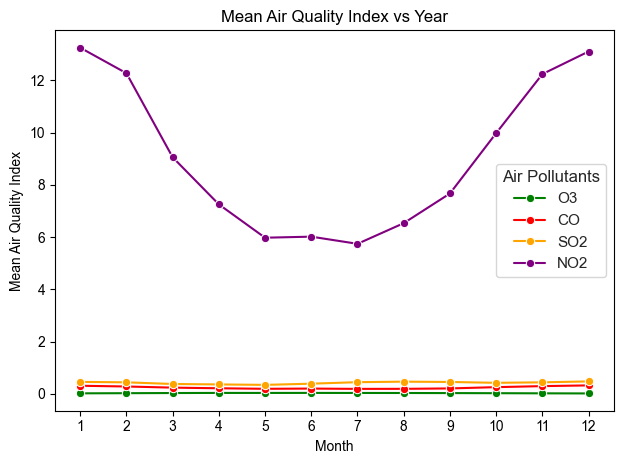

In [24]:
# Section 4: Visualizations and feature exploration
import seaborn as sns
import matplotlib.pyplot as plt
os.makedirs("figures", exist_ok=True)
fig, ax = plt.subplots()

sns.set_theme(style = "whitegrid")

# Monthly trend
monthly_trend = (df.groupby("Month")["Avg_AQI"]
                  .agg(["mean", "median", "std"])
                  .round(2)
                  .reset_index())

# Take negative Pollutant Means
df["O3 Mean"] = df["O3 Mean"].clip(lower=0)
df["CO Mean"] = df["CO Mean"].clip(lower=0)
df["SO2 Mean"] = df["SO2 Mean"].clip(lower=0)
df["NO2 Mean"] = df["NO2 Mean"].clip(lower=0)

# Line Plot (Mean Air Quality Index vs Year)
sns.lineplot(data = df, x="Month", y="O3 Mean", estimator="mean", marker="o", label="O3", color="green", errorbar=None)
sns.lineplot(data = df, x="Month", y="CO Mean", estimator="mean", marker="o", label="CO", color="red", errorbar=None)
sns.lineplot(data = df, x="Month", y="SO2 Mean", estimator="mean", marker="o", label="SO2", color="orange", errorbar=None)
sns.lineplot(data = df, x="Month", y="NO2 Mean", estimator="mean", marker="o", label="NO2", color="purple", errorbar=None)
plt.title("Mean Air Quality Index vs Year")
plt.xlabel("Month")
plt.ylabel("Mean Air Quality Index")
plt.legend(title = "Air Pollutants")
plt.tight_layout()

plt.xticks(monthly_trend["Month"])
fig.savefig("figures/mean-aqi-vs-year.pdf", dpi=300)
plt.show()

/var/folders/dt/v81ky6851gsfwjvm__kb4fyc0000gp/T/ipykernel_6842/2448865008.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


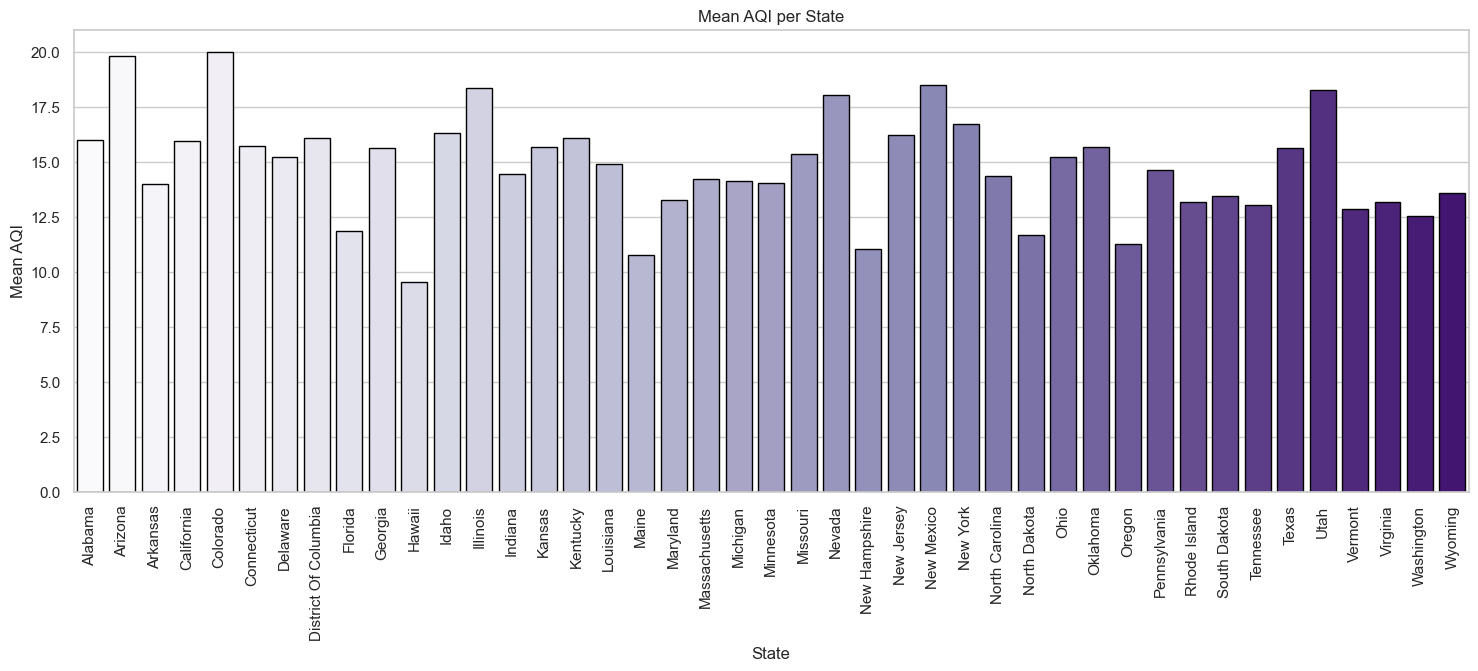

In [25]:
# Bar Plot (Mean AQI per State)
# df.head()
plt.figure(figsize=(18, 6))

sns.barplot(
    data=df,
    x="State",
    y = "Avg_AQI", estimator = "mean",
    palette="Purples", errorbar=None, edgecolor="black"
)

plt.title("Mean AQI per State")
plt.xlabel("State")
plt.ylabel("Mean AQI")
plt.xticks(rotation=90)
fig.savefig("figures/mean-aqi-per-state.pdf", dpi=300)
plt.show()

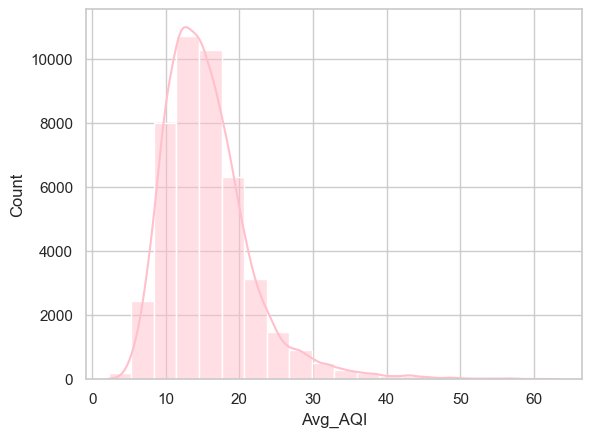

In [26]:
# Histogram with KDE (Distribution of Average AQI)
sns.histplot(data = df, x = "Avg_AQI", bins = 20, color="pink", kde = True)
ax.set_title("Distribution of Average Air Quality Index (AQI)")
ax.set_xlabel("Average Air Quality Index")
ax.set_ylabel("Frequency")
fig.savefig("figures/distribution-avg-aqi.pdf", dpi=300)
plt.show()

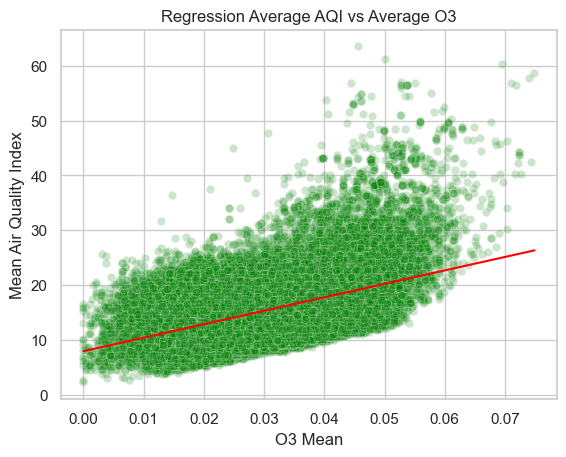

In [27]:
# Scatter Plot with Regression Line (Avg_AQI vs O3 Mean)
sns.scatterplot(data=df, x="O3 Mean", y="Avg_AQI", alpha=0.2, color="green")
m,b = np.polyfit(df["O3 Mean"], df['Avg_AQI'], 1)
sns.lineplot(data=df, x="O3 Mean",y =  m*df["O3 Mean"]+b, color="red")
plt.title("Regression Average AQI vs Average O3")
plt.xlabel("O3 Mean")
plt.ylabel("Mean Air Quality Index")
fig.savefig("figures/regression-avgaqi-vs-avgo3.pdf", dpi=300)
plt.show()

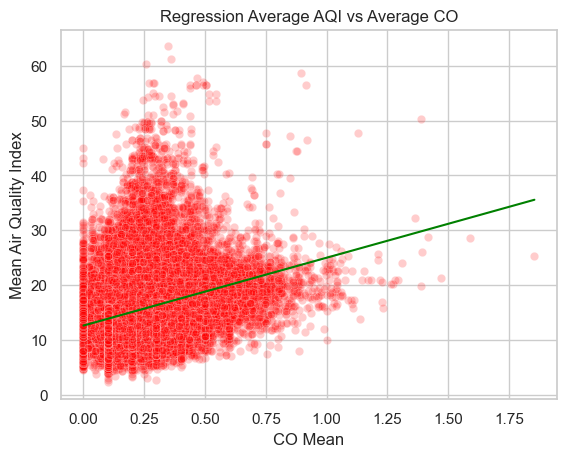

In [28]:
# Scatter Plot with Regression Line (Avg_AQI vs CO Mean)
sns.scatterplot(data=df, x="CO Mean", y="Avg_AQI", alpha=0.2, color="red")
m,b = np.polyfit(df["CO Mean"], df['Avg_AQI'], 1)
sns.lineplot(data=df, x="CO Mean",y =  m*df["CO Mean"]+b, color="green")
plt.title("Regression Average AQI vs Average CO")
plt.xlabel("CO Mean")
plt.ylabel("Mean Air Quality Index")
fig.savefig("figures/regression-avgaqi-vs-avgco.pdf", dpi=300)
plt.show()

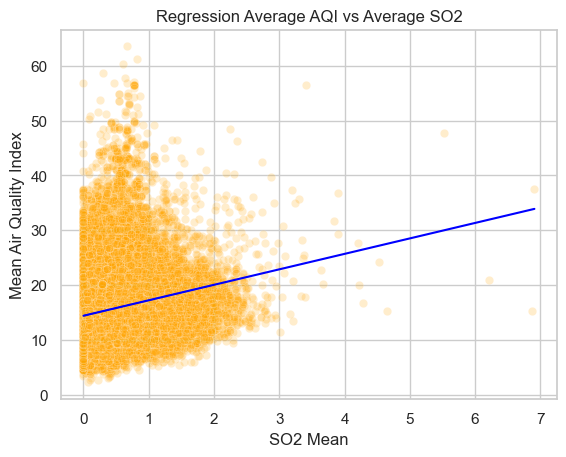

In [29]:
# Scatter Plot with Regression Line (Avg_AQI vs SO2 Mean)
sns.scatterplot(data=df, x="SO2 Mean", y="Avg_AQI", alpha=0.2, color="orange")
m,b = np.polyfit(df["SO2 Mean"], df['Avg_AQI'], 1)
sns.lineplot(data=df, x="SO2 Mean",y =  m*df["SO2 Mean"]+b, color="blue")
plt.title("Regression Average AQI vs Average SO2")
plt.xlabel("SO2 Mean")
plt.ylabel("Mean Air Quality Index")
fig.savefig("figures/regression-avgaqi-vs-avgso2.pdf", dpi=300)
plt.show()

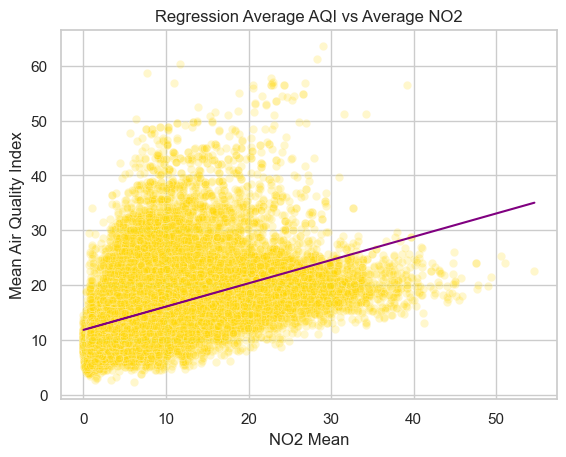

In [30]:

# Scatter Plot with Regression Line (Avg_AQI vs NO2 Mean)
sns.scatterplot(data=df, x="NO2 Mean", y="Avg_AQI", alpha=0.2, color="gold")
m,b = np.polyfit(df["NO2 Mean"], df['Avg_AQI'], 1)
sns.lineplot(data=df, x="NO2 Mean",y =  m*df["NO2 Mean"]+b, color="purple")
plt.title("Regression Average AQI vs Average NO2")
plt.xlabel("NO2 Mean")
plt.ylabel("Mean Air Quality Index")
fig.savefig("figures/regression-avgaqi-vs-avgno2.pdf", dpi=300)
plt.show()

# 5. Summary and Key Findings

## Summary:

This analysis examined air quality across the US using 44,726 observations from 2022–2023. We tracked four major pollutants: O₃ (Ozone), CO (Carbon Monoxide), SO₂ (Sulfur Dioxide), NO₂ (Nitrogen Dioxide). After cleaning, type conversions, and missing value handling, we derived new features such as average AQI per day and O₃ pollution categories (Good / Moderate / Unhealthy)

Key Findings:

## Key Insights

### 1. Overall Air Quality
- The national average AQI increased from 15.40 in 2022 to 15.92 in 2023, indicating that air quality has worsened slightly from 2022 to 2023.  
- 38377 days fell into the Good O₃ category, 5528 into the Moderate category, and 821 into the Unhealthy category.

### 2. State-Level Differences
- Air quality varies significantly across states. The top 10 states by mean AQI are:  
  1. Colorado — 20.02  
  2. Arizona — 19.81  
  3. New Mexico — 18.51  
  4. Illinois — 18.37  
  5. Utah — 18.27  
  6. Nevada — 18.07  
  7. New York — 16.73  
  8. Idaho — 16.30  
  9. New Jersey — 16.23  
  10. Kentucky — 16.10  
- Florida had lower AQI values (between 11.0–14.8), showing regional differences within the state.

### 3. Pollutant Contributions
- Ozone (O₃) spent the most days as the worst pollutant, with 39363 days. NO₂ was second with 5349 days. SO₂ and CO were rare, spending 10 and 4 days respectively.  
- O₃ shows the strongest correlation with Avg_AQI (0.80), confirming it as the main causer of poor air quality.

### 4. AQI by Category
- Average AQI by O₃ category:  
  - Good: 14.07  
  - Moderate: 22.80  
  - Unhealthy: 37.75  
- Other pollutants (CO, SO₂, NO₂) remain relatively low across all categories. However, NO₂ contributes more in Moderate and Unhealthy conditions.  

### 5. Trends and Correlations
- Correlation matrix shows CO and NO₂ moderately correlate with Avg_AQI (0.36 and 0.62, respectively), while SO₂ has a smaller effect (0.19).  
- Controlling O₃ is important, but reducing NO₂ and CO can also improve air quality.

## Interpretation
Air quality across the U.S. is generally moderate, with significant differences by state. Ozone is the main pollutant affecting average AQI. While most days are “Good,” some states show consistently higher pollution. The slight increase in national average AQI from 2022 to 2023 demonstrate the need for continued intervention against pollutants.